In [1]:
#import libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
#import dataset
df = pd.read_excel("C:/Users/Mohammad Adnan/Downloads/data.xlsx")

In [3]:
df.head()

,Restaurant ID,Restaurant Name,Country Code,City,Address,Locality,Locality Verbose,Longitude,Latitude,Cuisines,Average Cost for two,Currency,Has Table booking,Has Online delivery,Price range,Aggregate rating,Rating color,Rating text,Votes
0,7402935,Skye,94,Jakarta,"Menara BCA, Lantai 56, Jl. MH. Thamrin, Thamri...","Grand Indonesia Mall, Thamrin","Grand Indonesia Mall, Thamrin, Jakarta",106.821999,-6.196778,"Italian, Continental",800000,Indonesian Rupiah(IDR),No,No,3,4.1,Green,Very Good,1498
1,7410290,Satoo - Hotel Shangri-La,94,Jakarta,"Hotel Shangri-La, Jl. Jend. Sudirman","Hotel Shangri-La, Sudirman","Hotel Shangri-La, Sudirman, Jakarta",106.818961,-6.203292,"Asian, Indonesian, Western",800000,Indonesian Rupiah(IDR),No,No,3,4.6,Dark Green,Excellent,873
2,7420899,Sushi Masa,94,Jakarta,"Jl. Tuna Raya No. 5, Penjaringan",Penjaringan,"Penjaringan, Jakarta",106.800144,-6.101298,"Sushi, Japanese",500000,Indonesian Rupiah(IDR),No,No,3,4.9,Dark Green,Excellent,605
3,7421967,3 Wise Monkeys,94,Jakarta,"Jl. Suryo No. 26, Senopati, Jakarta",Senopati,"Senopati, Jakarta",106.813400,-6.235241,Japanese,450000,Indonesian Rupiah(IDR),No,No,3,4.2,Green,Very Good,395
4,7422489,Avec Moi Restaurant and Bar,94,Jakarta,"Gedung PIC, Jl. Teluk Betung 43, Thamrin, Jakarta",Thamrin,"Thamrin, Jakarta",106.821023,-6.196270,"French, Western",350000,Indonesian Rupiah(IDR),No,No,3,4.3,Green,Very Good,243


# 1. Perform preliminary data inspection and report the findings as the structure of the data, missing values, duplicates, etc.

In [5]:
structure = df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9551 entries, 0 to 9550
Data columns (total 19 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Restaurant ID         9551 non-null   int64  
 1   Restaurant Name       9550 non-null   object 
 2   Country Code          9551 non-null   int64  
 3   City                  9551 non-null   object 
 4   Address               9551 non-null   object 
 5   Locality              9551 non-null   object 
 6   Locality Verbose      9551 non-null   object 
 7   Longitude             9551 non-null   float64
 8   Latitude              9551 non-null   float64
 9   Cuisines              9542 non-null   object 
 10  Average Cost for two  9551 non-null   int64  
 11  Currency              9551 non-null   object 
 12  Has Table booking     9551 non-null   object 
 13  Has Online delivery   9551 non-null   object 
 14  Price range           9551 non-null   int64  
 15  Aggregate rating     

In [6]:
# Preliminary data inspection
missing_values = df.isnull().sum()

In [7]:
duplicates = df.duplicated().sum()

In [8]:
# Clean the variable names
df.columns = df.columns.str.lower().str.replace(" " , "_")

In [9]:
df.columns

Index(['restaurant_id', 'restaurant_name', 'country_code', 'city', 'address',
       'locality', 'locality_verbose', 'longitude', 'latitude', 'cuisines',
       'average_cost_for_two', 'currency', 'has_table_booking',
       'has_online_delivery', 'price_range', 'aggregate_rating',
       'rating_color', 'rating_text', 'votes'],
      dtype='object')

# 2. Based on the findings from the previous questions, identify duplicates and remove them

In [11]:
# Handle missing values
df['restaurant_name'] == np.nan

0       False
1       False
2       False
3       False
4       False
        ...  
9546    False
9547    False
9548    False
9549    False
9550    False
Name: restaurant_name, Length: 9551, dtype: bool

In [12]:
df['restaurant_name'].unique()

array(['Skye', 'Satoo - Hotel Shangri-La', 'Sushi Masa', ...,
       'UrbanCrave', 'Deena Chat Bhandar', 'VNS Live Studio'],
      dtype=object)

In [13]:
df['restaurant_name'].value_counts()

restaurant_name
Cafe Coffee Day                          83
Domino's Pizza                           79
Subway                                   63
Green Chick Chop                         51
McDonald's                               48
                                         ..
The Chickmunks CafÌ©                      1
Punjabi Chaska                            1
Amrit's Agni Multi Cuisine Restaurant     1
Quick Grabs                               1
VNS Live Studio                           1
Name: count, Length: 7445, dtype: int64

In [14]:
df_cleaned = df.dropna(subset = 'restaurant_name')

In [15]:
# Summary after cleaning

Summary_after_cleaning = {
    "missing_values_after_cleaning" : df_cleaned.isnull().sum(),
    "duplicates_after_cleaning" : df_cleaned.duplicated().sum(),
    "unique_has_table_booking" : df_cleaned['has_table_booking'].unique(),
    "unique_has_online_delivery" : df_cleaned['has_online_delivery'].unique() }

#print(structure)
print("Missing values before cleaning :", missing_values)
print("Duplicates before cleaning :" , duplicates)
print("Variable names after cleaning :" , df.columns)
print("Missing values after cleaning :" , Summary_after_cleaning['missing_values_after_cleaning'])
print("Duplicates after cleaning :" , Summary_after_cleaning['duplicates_after_cleaning'])
print("Unique has_table_booking values :", Summary_after_cleaning['unique_has_table_booking'])
print("Unique has_online_delivery values :" , Summary_after_cleaning['unique_has_online_delivery'])

Missing values before cleaning : Restaurant ID           0
Restaurant Name         1
Country Code            0
City                    0
Address                 0
Locality                0
Locality Verbose        0
Longitude               0
Latitude                0
Cuisines                9
Average Cost for two    0
Currency                0
Has Table booking       0
Has Online delivery     0
Price range             0
Aggregate rating        0
Rating color            0
Rating text             0
Votes                   0
dtype: int64
Duplicates before cleaning : 0
Variable names after cleaning : Index(['restaurant_id', 'restaurant_name', 'country_code', 'city', 'address',
       'locality', 'locality_verbose', 'longitude', 'latitude', 'cuisines',
       'average_cost_for_two', 'currency', 'has_table_booking',
       'has_online_delivery', 'price_range', 'aggregate_rating',
       'rating_color', 'rating_text', 'votes'],
      dtype='object')
Missing values after cleaning : restaurant_i

# 3. Explore the geographical distribution of the restaurants and identify the cities with the maximum and minimum number of restaurants

In [17]:
df_cleaned.info()

<class 'pandas.core.frame.DataFrame'>
Index: 9550 entries, 0 to 9550
Data columns (total 19 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   restaurant_id         9550 non-null   int64  
 1   restaurant_name       9550 non-null   object 
 2   country_code          9550 non-null   int64  
 3   city                  9550 non-null   object 
 4   address               9550 non-null   object 
 5   locality              9550 non-null   object 
 6   locality_verbose      9550 non-null   object 
 7   longitude             9550 non-null   float64
 8   latitude              9550 non-null   float64
 9   cuisines              9541 non-null   object 
 10  average_cost_for_two  9550 non-null   int64  
 11  currency              9550 non-null   object 
 12  has_table_booking     9550 non-null   object 
 13  has_online_delivery   9550 non-null   object 
 14  price_range           9550 non-null   int64  
 15  aggregate_rating      9550

In [18]:
# Explore the geograpical distributions of restaurants
city_counts = df_cleaned['city'].value_counts()

In [19]:
# identify the cities with the maximum and minimum number of restaurants
maximum_restaurants_city = city_counts.idxmax()
maximum_restaurants_count = city_counts.max()
minimum_restaurants_city = city_counts.idxmin()
minimun_restaurants_count = city_counts.min()

print(f"City with maximum no of restaurants : {maximum_restaurants_city} ( {maximum_restaurants_count} restaurants )")
print(f"City with minimum no of restaurants : {minimum_restaurants_city} ( {minimun_restaurants_count} restaurants )")

City with maximum no of restaurants : New Delhi ( 5473 restaurants )
City with minimum no of restaurants : Phillip Island ( 1 restaurants )


# 4. Restaurant franchising is a thriving venture. So, it is very important to explore the franchise with most national presence

In [21]:
df_cleaned.info()

<class 'pandas.core.frame.DataFrame'>
Index: 9550 entries, 0 to 9550
Data columns (total 19 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   restaurant_id         9550 non-null   int64  
 1   restaurant_name       9550 non-null   object 
 2   country_code          9550 non-null   int64  
 3   city                  9550 non-null   object 
 4   address               9550 non-null   object 
 5   locality              9550 non-null   object 
 6   locality_verbose      9550 non-null   object 
 7   longitude             9550 non-null   float64
 8   latitude              9550 non-null   float64
 9   cuisines              9541 non-null   object 
 10  average_cost_for_two  9550 non-null   int64  
 11  currency              9550 non-null   object 
 12  has_table_booking     9550 non-null   object 
 13  has_online_delivery   9550 non-null   object 
 14  price_range           9550 non-null   int64  
 15  aggregate_rating      9550

In [22]:
# franchise with most national presence
franchise_presence = df_cleaned.groupby(['restaurant_name'])['city'].nunique().sort_values(ascending=False)
franchise_presence
top_franchise = franchise_presence.idxmax()
top_franchise_city = franchise_presence.max()

print(f" The franchise with most national presence is {top_franchise} present in {top_franchise_city} cities ")

 The franchise with most national presence is Barbeque Nation present in 22 cities 


# 5. Find out the ratio between restaurants that allow table booking vs. those that do not allow table booking

In [24]:
df_cleaned.info()

<class 'pandas.core.frame.DataFrame'>
Index: 9550 entries, 0 to 9550
Data columns (total 19 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   restaurant_id         9550 non-null   int64  
 1   restaurant_name       9550 non-null   object 
 2   country_code          9550 non-null   int64  
 3   city                  9550 non-null   object 
 4   address               9550 non-null   object 
 5   locality              9550 non-null   object 
 6   locality_verbose      9550 non-null   object 
 7   longitude             9550 non-null   float64
 8   latitude              9550 non-null   float64
 9   cuisines              9541 non-null   object 
 10  average_cost_for_two  9550 non-null   int64  
 11  currency              9550 non-null   object 
 12  has_table_booking     9550 non-null   object 
 13  has_online_delivery   9550 non-null   object 
 14  price_range           9550 non-null   int64  
 15  aggregate_rating      9550

In [25]:
# Calculate the ratio of restaurants that allow table booking vs those that do not
table_booking_counts = df_cleaned['has_table_booking'].value_counts()

In [26]:
if 'yes' in table_booking_counts and 'no' in table_booking_counts :
    ratio = table_booking_counts['yes']/table_booking_counts['no']
else :
    ratio = None

In [27]:
# the ratio between restaurants that allow table booking vs. those that do not allow table booking

ratio = ((1135)/(6298))*100

print(f"The ratio between restaurants that allow table booking vs. those that do not allow table booking is : {ratio:.2f}%")

The ratio between restaurants that allow table booking vs. those that do not allow table booking is : 18.02%


# 6. Find out the percentage of restaurants providing online delivery

In [29]:
df_cleaned.info()

<class 'pandas.core.frame.DataFrame'>
Index: 9550 entries, 0 to 9550
Data columns (total 19 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   restaurant_id         9550 non-null   int64  
 1   restaurant_name       9550 non-null   object 
 2   country_code          9550 non-null   int64  
 3   city                  9550 non-null   object 
 4   address               9550 non-null   object 
 5   locality              9550 non-null   object 
 6   locality_verbose      9550 non-null   object 
 7   longitude             9550 non-null   float64
 8   latitude              9550 non-null   float64
 9   cuisines              9541 non-null   object 
 10  average_cost_for_two  9550 non-null   int64  
 11  currency              9550 non-null   object 
 12  has_table_booking     9550 non-null   object 
 13  has_online_delivery   9550 non-null   object 
 14  price_range           9550 non-null   int64  
 15  aggregate_rating      9550

In [30]:
df_cleaned['has_online_delivery'].unique()

array(['No', 'Yes'], dtype=object)

In [31]:
# percentage of restaurants providing online delivery

ratio = (2334/7433)*100

print(f"percentage of restaurants providing online delivery is {ratio:.2f}%")

percentage of restaurants providing online delivery is 31.40%


# 7. Calculate the difference in number of votes for the restaurants that deliver and the restaurants that do not deliver

In [33]:
df_cleaned.info()

<class 'pandas.core.frame.DataFrame'>
Index: 9550 entries, 0 to 9550
Data columns (total 19 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   restaurant_id         9550 non-null   int64  
 1   restaurant_name       9550 non-null   object 
 2   country_code          9550 non-null   int64  
 3   city                  9550 non-null   object 
 4   address               9550 non-null   object 
 5   locality              9550 non-null   object 
 6   locality_verbose      9550 non-null   object 
 7   longitude             9550 non-null   float64
 8   latitude              9550 non-null   float64
 9   cuisines              9541 non-null   object 
 10  average_cost_for_two  9550 non-null   int64  
 11  currency              9550 non-null   object 
 12  has_table_booking     9550 non-null   object 
 13  has_online_delivery   9550 non-null   object 
 14  price_range           9550 non-null   int64  
 15  aggregate_rating      9550

In [34]:
# Filter the DataFrame based on the 'Has Online delivery' column
Online_delivery_votes = df_cleaned[df_cleaned['has_online_delivery']=='Yes']['votes']
No_online_delivery_votes = df_cleaned[df_cleaned['has_online_delivery']=='No']['votes']


        

In [35]:
# Calculate the average number of votes for each group
Average_votes_online_delivery = Online_delivery_votes.mean()
Average_votes_no_online_delivery = No_online_delivery_votes.mean()


In [36]:
# Print the results
votes_difference = Average_votes_online_delivery - Average_votes_no_online_delivery
# Check the difference in number of votes
print(f"The difference in number of votes for the restaurants that deliver and the restaurants that do not deliver is {votes_difference:.2f}")

The difference in number of votes for the restaurants that deliver and the restaurants that do not deliver is 73.26


# 1. What are the top 10 cuisines served across cities?

In [38]:
df_cleaned.info()

<class 'pandas.core.frame.DataFrame'>
Index: 9550 entries, 0 to 9550
Data columns (total 19 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   restaurant_id         9550 non-null   int64  
 1   restaurant_name       9550 non-null   object 
 2   country_code          9550 non-null   int64  
 3   city                  9550 non-null   object 
 4   address               9550 non-null   object 
 5   locality              9550 non-null   object 
 6   locality_verbose      9550 non-null   object 
 7   longitude             9550 non-null   float64
 8   latitude              9550 non-null   float64
 9   cuisines              9541 non-null   object 
 10  average_cost_for_two  9550 non-null   int64  
 11  currency              9550 non-null   object 
 12  has_table_booking     9550 non-null   object 
 13  has_online_delivery   9550 non-null   object 
 14  price_range           9550 non-null   int64  
 15  aggregate_rating      9550

In [39]:
# Split the 'Cuisines' column into multiple cuisines
Cuisine_series = df_cleaned['cuisines'].str.split(',').explode().str.strip()

In [40]:
# Count the occurrences of each cuisine
Cuisine_count = Cuisine_series.value_counts()


In [41]:
# Get the top 10 cuisines
Top_10_cuisines = Cuisine_count.head(10)
# Print the results
print(f"The top 10 cuisines served across cities are {Top_10_cuisines}")

The top 10 cuisines served across cities are cuisines
North Indian    3959
Chinese         2735
Fast Food       1986
Mughlai          995
Italian          763
Bakery           745
Continental      735
Cafe             703
Desserts         653
South Indian     636
Name: count, dtype: int64


# 2. What is the maximum and minimum number of cuisines that a restaurant serves? Also, which is the most served cuisine across the restaurant for each city?

In [43]:
df_cleaned.info()

<class 'pandas.core.frame.DataFrame'>
Index: 9550 entries, 0 to 9550
Data columns (total 19 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   restaurant_id         9550 non-null   int64  
 1   restaurant_name       9550 non-null   object 
 2   country_code          9550 non-null   int64  
 3   city                  9550 non-null   object 
 4   address               9550 non-null   object 
 5   locality              9550 non-null   object 
 6   locality_verbose      9550 non-null   object 
 7   longitude             9550 non-null   float64
 8   latitude              9550 non-null   float64
 9   cuisines              9541 non-null   object 
 10  average_cost_for_two  9550 non-null   int64  
 11  currency              9550 non-null   object 
 12  has_table_booking     9550 non-null   object 
 13  has_online_delivery   9550 non-null   object 
 14  price_range           9550 non-null   int64  
 15  aggregate_rating      9550

In [44]:
# Fill NaN values with an empty string and then calculate the number of cuisines served by each restaurant
df_cleaned['No_cuisines'] = df_cleaned['cuisines'].fillna('').str.split(',').apply(len)

C:\Users\Mohammad Adnan\AppData\Local\Temp\ipykernel_21720\1883914687.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_cleaned['No_cuisines'] = df_cleaned['cuisines'].fillna('').str.split(',').apply(len)


In [45]:
# Group by 'restaurant_name' to find the maximum and minimum number of cuisines served by any restaurant
Cuisines_by_restaurant = df_cleaned.groupby(['restaurant_name'])['No_cuisines'].max()

In [46]:
# Find the restaurants that serve the maximum and minimum number of cuisines
Max_cuisines = Cuisines_by_restaurant.max()
Min_cuisines = Cuisines_by_restaurant.min()

print(f"Maximum and minimum number of cuisines that a restaurant serves are {Max_cuisines} and {Min_cuisines} ")

Maximum and minimum number of cuisines that a restaurant serves are 8 and 1 


In [47]:
df_cleaned.corr(numeric_only=True)

,restaurant_id,country_code,longitude,latitude,average_cost_for_two,price_range,aggregate_rating,votes,No_cuisines
restaurant_id,1.000000,0.148447,-0.226073,-0.052111,-0.001696,-0.134419,-0.326144,-0.146895,-0.074624
country_code,0.148447,1.000000,-0.698298,0.019784,0.043224,0.243393,0.282234,0.154593,0.009035
longitude,-0.226073,-0.698298,1.000000,0.043213,0.045892,-0.078974,-0.116843,-0.085141,0.014792
latitude,-0.052111,0.019784,0.043213,1.000000,-0.111089,-0.166668,0.000541,-0.022927,-0.028972
average_cost_for_two,-0.001696,0.043224,0.045892,-0.111089,1.000000,0.075093,0.051797,0.067794,0.013348
price_range,-0.134419,0.243393,-0.078974,-0.166668,0.075093,1.000000,0.437874,0.309308,0.312773
aggregate_rating,-0.326144,0.282234,-0.116843,0.000541,0.051797,0.437874,1.000000,0.313598,0.249271
votes,-0.146895,0.154593,-0.085141,-0.022927,0.067794,0.309308,0.313598,1.000000,0.183217
No_cuisines,-0.074624,0.009035,0.014792,-0.028972,0.013348,0.312773,0.249271,0.183217,1.000000


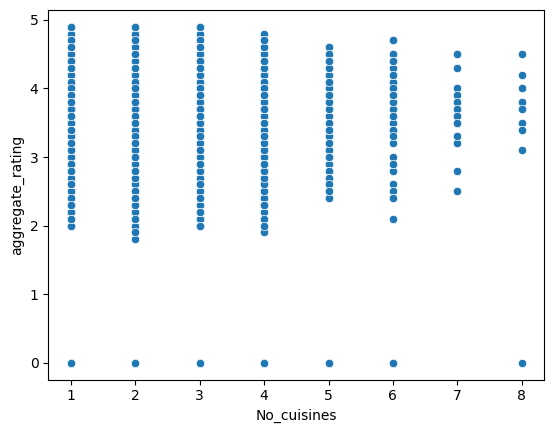

In [48]:
sns.scatterplot(x = 'No_cuisines' , y = 'aggregate_rating' , data = df_cleaned)
plt.show()

# 3. What is the distribution cost across the restaurants?

In [50]:
df_cleaned.info()

<class 'pandas.core.frame.DataFrame'>
Index: 9550 entries, 0 to 9550
Data columns (total 20 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   restaurant_id         9550 non-null   int64  
 1   restaurant_name       9550 non-null   object 
 2   country_code          9550 non-null   int64  
 3   city                  9550 non-null   object 
 4   address               9550 non-null   object 
 5   locality              9550 non-null   object 
 6   locality_verbose      9550 non-null   object 
 7   longitude             9550 non-null   float64
 8   latitude              9550 non-null   float64
 9   cuisines              9541 non-null   object 
 10  average_cost_for_two  9550 non-null   int64  
 11  currency              9550 non-null   object 
 12  has_table_booking     9550 non-null   object 
 13  has_online_delivery   9550 non-null   object 
 14  price_range           9550 non-null   int64  
 15  aggregate_rating      9550

In [51]:
# Select the columns for comparison
columns_to_compare = [ 'restaurant_name' , 'average_cost_for_two']


In [52]:
# Create a new DataFrame with the selected columns
comparision_df = df_cleaned[columns_to_compare]


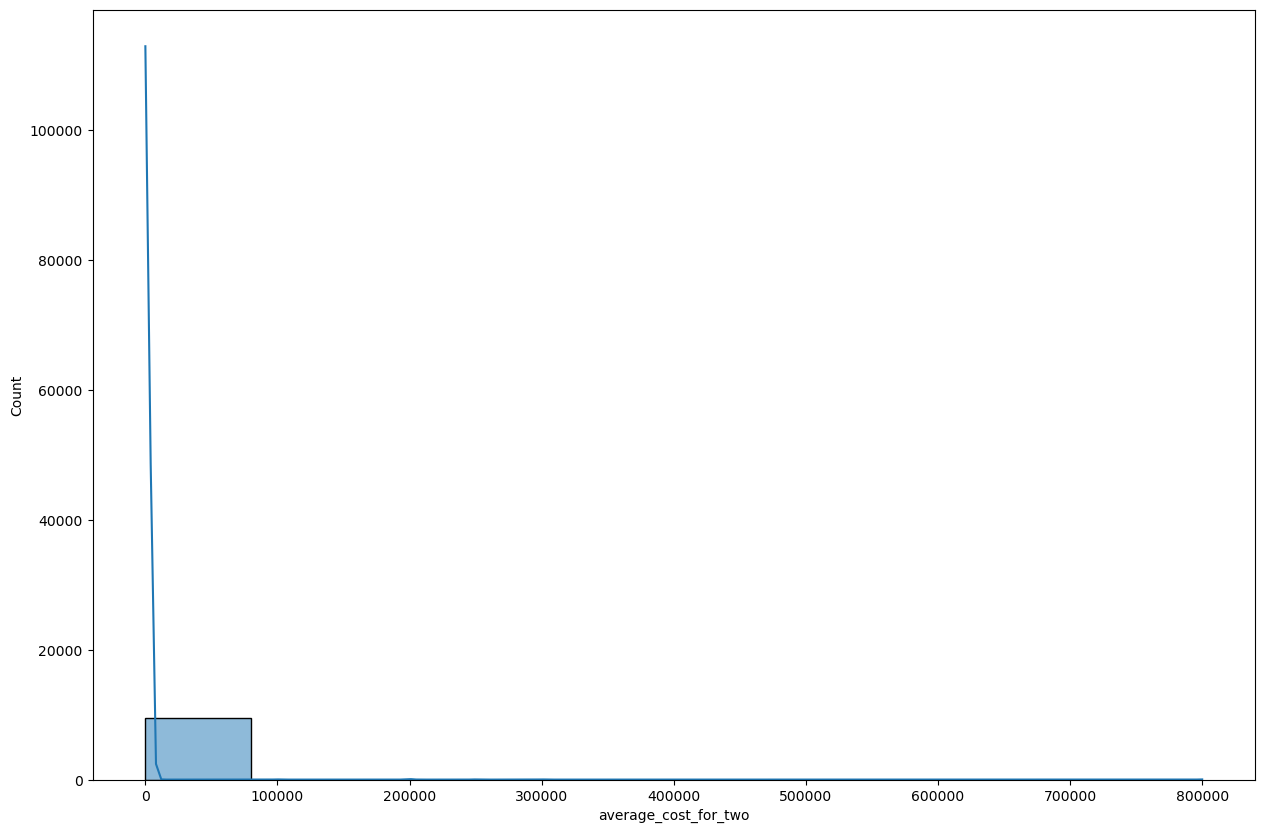

In [53]:
# Plot a histogram for 'average_cost_for_two'
plt.figure(figsize=(15,10))
sns.histplot( x = comparision_df['average_cost_for_two'] , data = comparision_df ,bins = 10 , kde = True)
plt.show()

In [54]:
comparision_df

,restaurant_name,average_cost_for_two
0,Skye,800000
1,Satoo - Hotel Shangri-La,800000
2,Sushi Masa,500000
3,3 Wise Monkeys,450000
4,Avec Moi Restaurant and Bar,350000
...,...,...
9546,BMG - All Day Dining,0
9547,Atmosphere Grill Cafe Sheesha,0
9548,UrbanCrave,0
9549,Deena Chat Bhandar,0


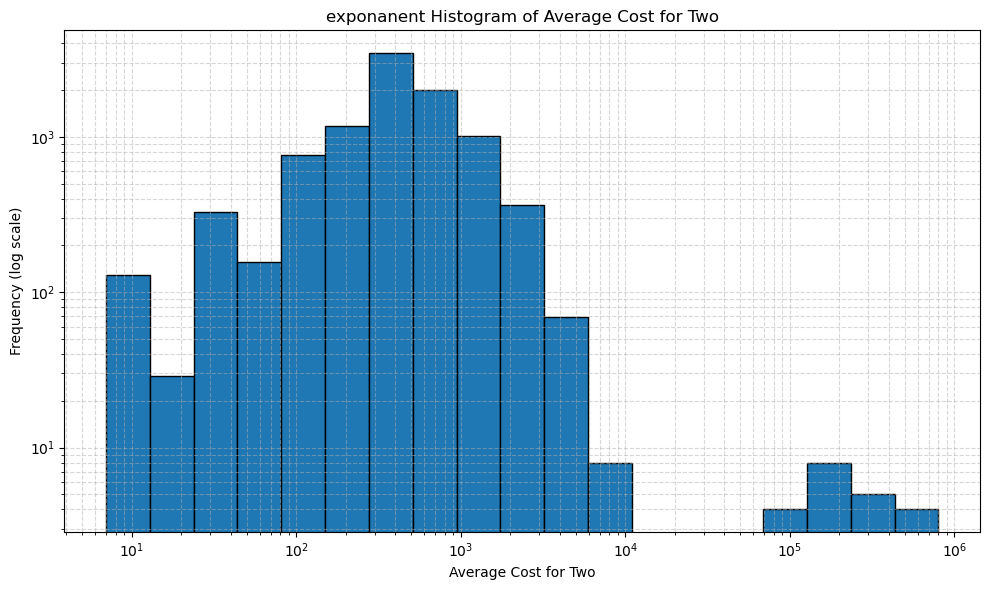

In [55]:
# Assuming average_cost_for_two is already int64 type
df['average_cost_for_two'] = pd.to_numeric(df['average_cost_for_two'], errors='coerce')

# Remove NaN values and any non-positive values (<= 0)
df = df.dropna()
df = df[df['average_cost_for_two'] > 0]

# Step 2: Create logarithmic bins
# Calculate the logarithmic bins
log_min = np.log10(df['average_cost_for_two'].min())
log_max = np.log10(df['average_cost_for_two'].max())
bins = np.logspace(log_min, log_max, 20)  # You can adjust the number of bins (20 in this case)

# Step 3: Plot the histogram
plt.figure(figsize=(10, 6))
plt.hist(df['average_cost_for_two'], bins=bins, edgecolor='black', log=True)
plt.xscale('log')
plt.xlabel('Average Cost for Two')
plt.ylabel('Frequency (log scale)')
plt.title('exponanent Histogram of Average Cost for Two')
plt.grid(True, which="both", ls="--", alpha=0.5)
plt.tight_layout()
plt.show()

# 4. How ratings are distributed among the various factors?

In [57]:
df_cleaned.info()

<class 'pandas.core.frame.DataFrame'>
Index: 9550 entries, 0 to 9550
Data columns (total 20 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   restaurant_id         9550 non-null   int64  
 1   restaurant_name       9550 non-null   object 
 2   country_code          9550 non-null   int64  
 3   city                  9550 non-null   object 
 4   address               9550 non-null   object 
 5   locality              9550 non-null   object 
 6   locality_verbose      9550 non-null   object 
 7   longitude             9550 non-null   float64
 8   latitude              9550 non-null   float64
 9   cuisines              9541 non-null   object 
 10  average_cost_for_two  9550 non-null   int64  
 11  currency              9550 non-null   object 
 12  has_table_booking     9550 non-null   object 
 13  has_online_delivery   9550 non-null   object 
 14  price_range           9550 non-null   int64  
 15  aggregate_rating      9550

In [58]:
df_cleaned.head()

,restaurant_id,restaurant_name,country_code,city,address,locality,locality_verbose,longitude,latitude,cuisines,average_cost_for_two,currency,has_table_booking,has_online_delivery,price_range,aggregate_rating,rating_color,rating_text,votes,No_cuisines
0,7402935,Skye,94,Jakarta,"Menara BCA, Lantai 56, Jl. MH. Thamrin, Thamri...","Grand Indonesia Mall, Thamrin","Grand Indonesia Mall, Thamrin, Jakarta",106.821999,-6.196778,"Italian, Continental",800000,Indonesian Rupiah(IDR),No,No,3,4.1,Green,Very Good,1498,2
1,7410290,Satoo - Hotel Shangri-La,94,Jakarta,"Hotel Shangri-La, Jl. Jend. Sudirman","Hotel Shangri-La, Sudirman","Hotel Shangri-La, Sudirman, Jakarta",106.818961,-6.203292,"Asian, Indonesian, Western",800000,Indonesian Rupiah(IDR),No,No,3,4.6,Dark Green,Excellent,873,3
2,7420899,Sushi Masa,94,Jakarta,"Jl. Tuna Raya No. 5, Penjaringan",Penjaringan,"Penjaringan, Jakarta",106.800144,-6.101298,"Sushi, Japanese",500000,Indonesian Rupiah(IDR),No,No,3,4.9,Dark Green,Excellent,605,2
3,7421967,3 Wise Monkeys,94,Jakarta,"Jl. Suryo No. 26, Senopati, Jakarta",Senopati,"Senopati, Jakarta",106.813400,-6.235241,Japanese,450000,Indonesian Rupiah(IDR),No,No,3,4.2,Green,Very Good,395,1
4,7422489,Avec Moi Restaurant and Bar,94,Jakarta,"Gedung PIC, Jl. Teluk Betung 43, Thamrin, Jakarta",Thamrin,"Thamrin, Jakarta",106.821023,-6.196270,"French, Western",350000,Indonesian Rupiah(IDR),No,No,3,4.3,Green,Very Good,243,2


In [59]:
df_cleaned.corr(numeric_only=True)

,restaurant_id,country_code,longitude,latitude,average_cost_for_two,price_range,aggregate_rating,votes,No_cuisines
restaurant_id,1.000000,0.148447,-0.226073,-0.052111,-0.001696,-0.134419,-0.326144,-0.146895,-0.074624
country_code,0.148447,1.000000,-0.698298,0.019784,0.043224,0.243393,0.282234,0.154593,0.009035
longitude,-0.226073,-0.698298,1.000000,0.043213,0.045892,-0.078974,-0.116843,-0.085141,0.014792
latitude,-0.052111,0.019784,0.043213,1.000000,-0.111089,-0.166668,0.000541,-0.022927,-0.028972
average_cost_for_two,-0.001696,0.043224,0.045892,-0.111089,1.000000,0.075093,0.051797,0.067794,0.013348
price_range,-0.134419,0.243393,-0.078974,-0.166668,0.075093,1.000000,0.437874,0.309308,0.312773
aggregate_rating,-0.326144,0.282234,-0.116843,0.000541,0.051797,0.437874,1.000000,0.313598,0.249271
votes,-0.146895,0.154593,-0.085141,-0.022927,0.067794,0.309308,0.313598,1.000000,0.183217
No_cuisines,-0.074624,0.009035,0.014792,-0.028972,0.013348,0.312773,0.249271,0.183217,1.000000


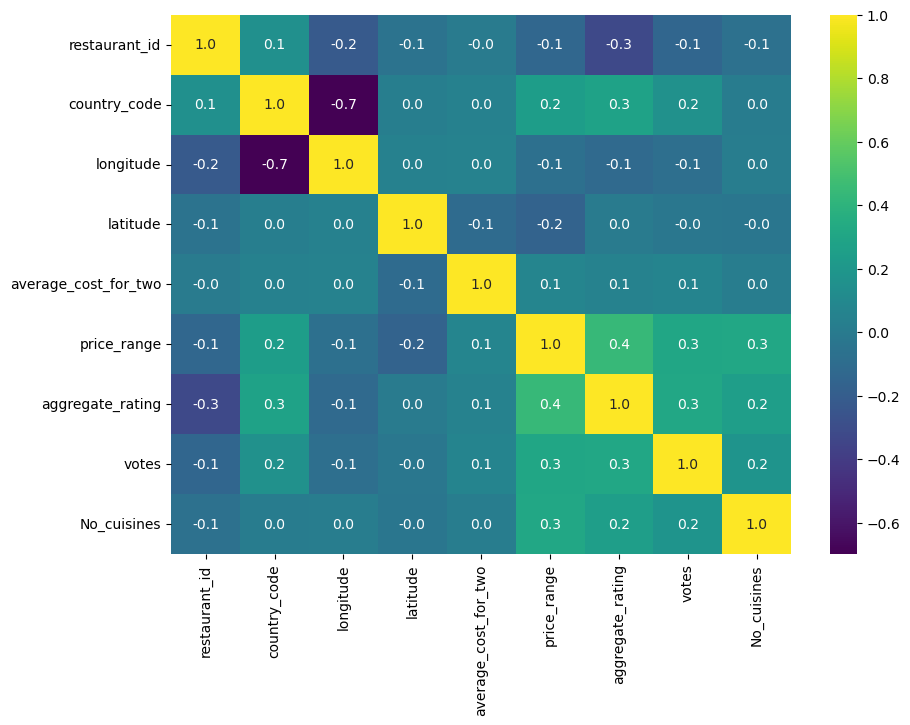

In [172]:
# Using heatmap

plt.figure(figsize = (10,7))
plt.tight_layout()
correlation = df_cleaned.corr(numeric_only=True)
sns.heatmap(correlation , annot=True , cmap='viridis' , fmt = '.1f')
plt.show()

In [60]:
factors = ['restaurant_id' , 'country_code' , 'longitude' , 'latitude' , 'average_cost_for_two' , 'price_range' , 'votes' , 'No_cuisines' , 'has_table_booking' , 'has_online_delivery']
    

<Figure size 1000x800 with 0 Axes>

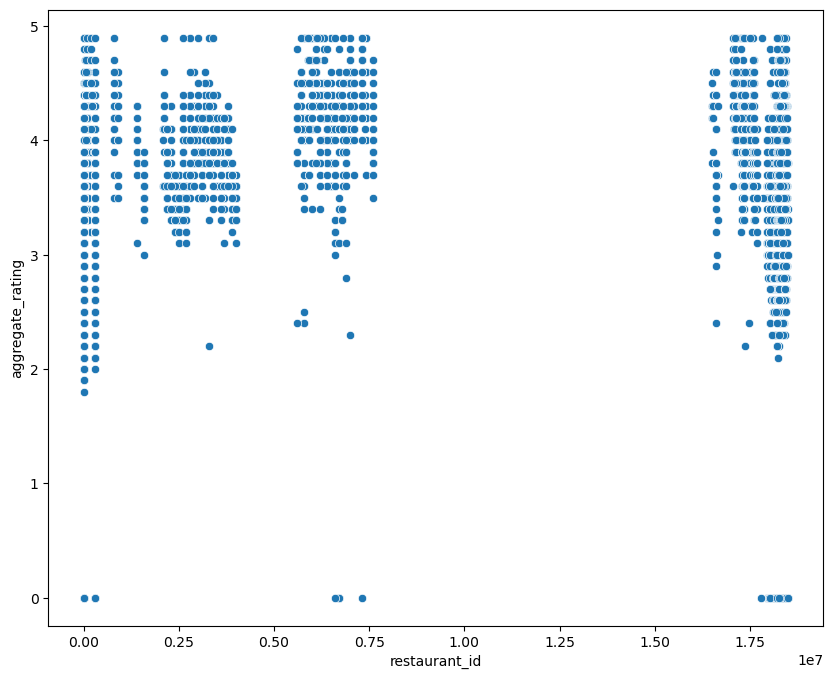

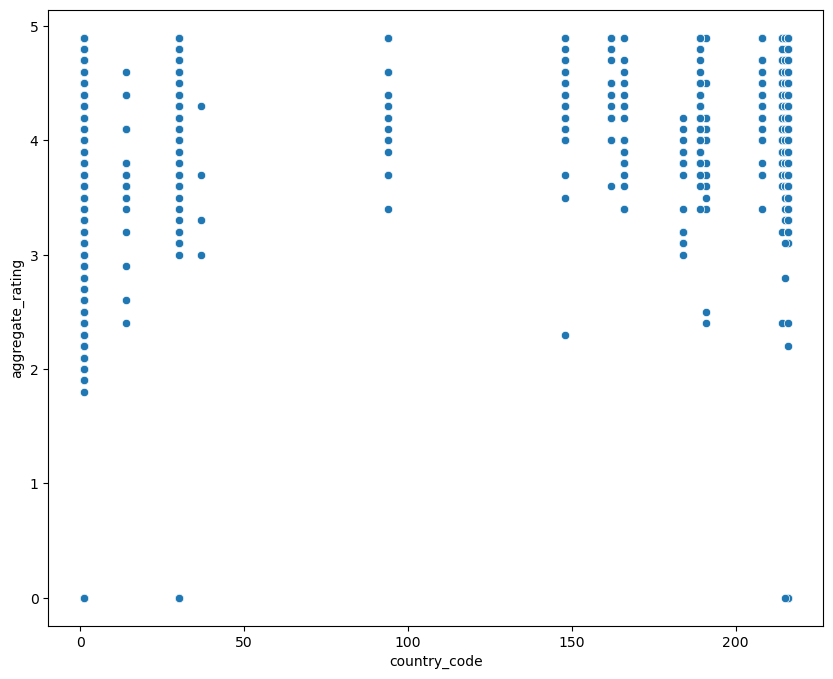

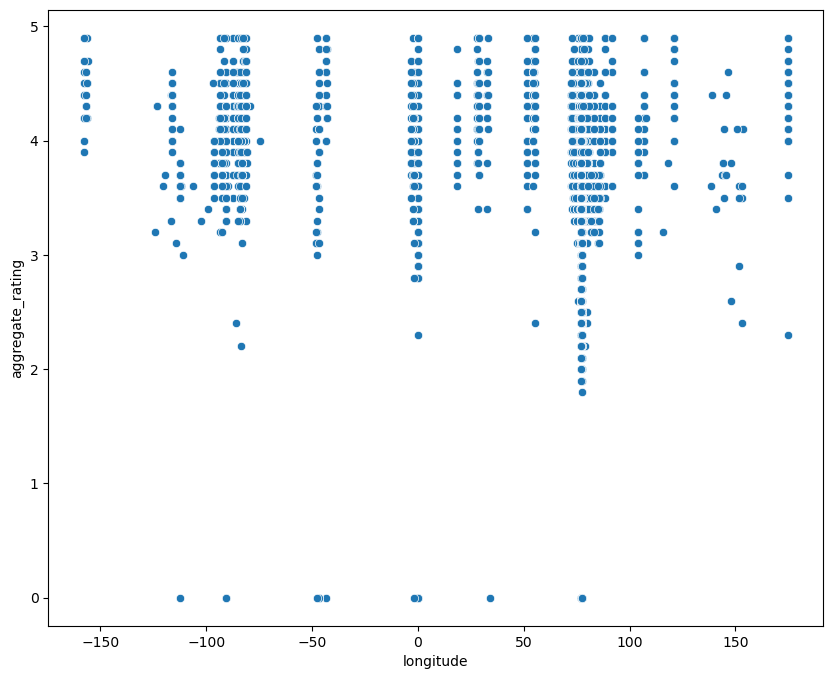

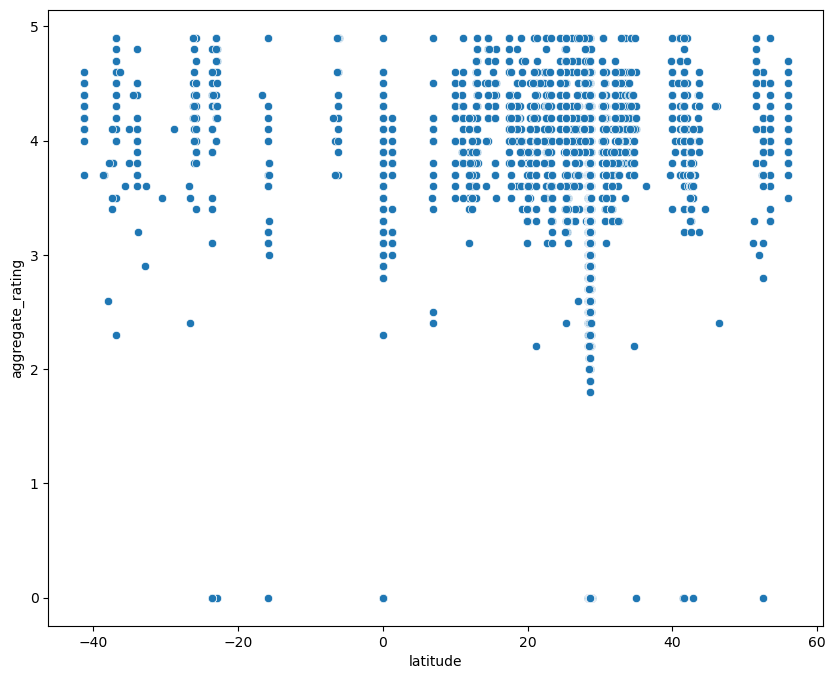

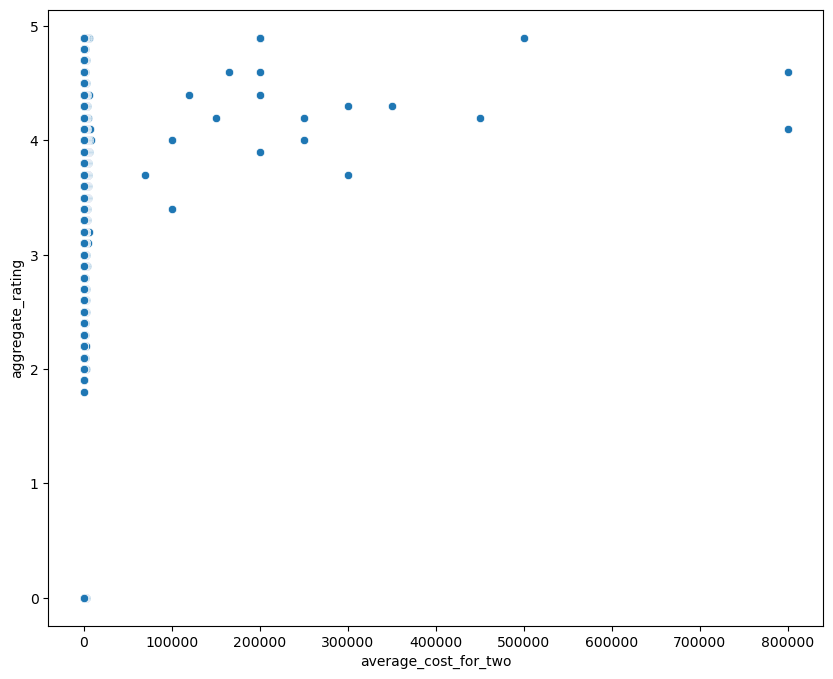

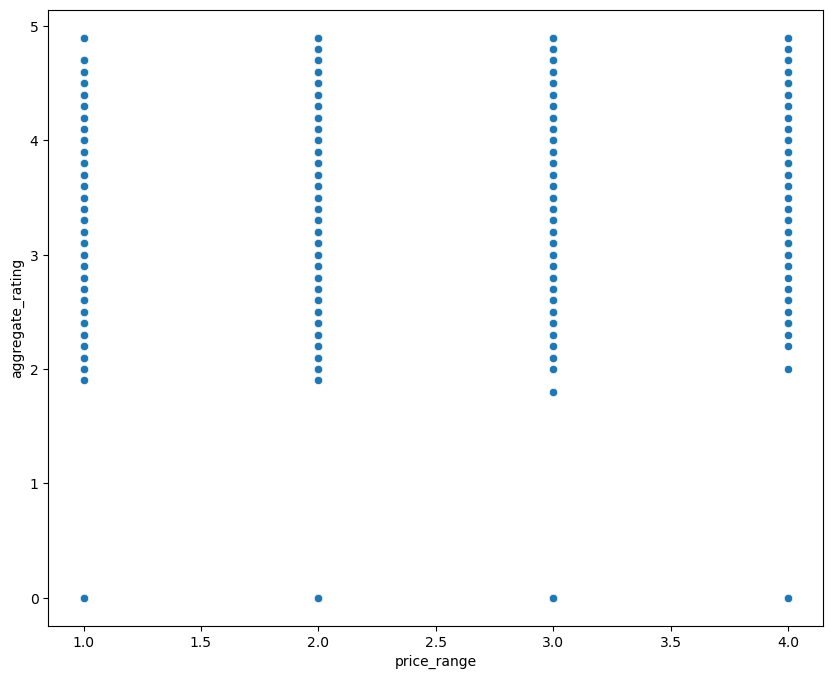

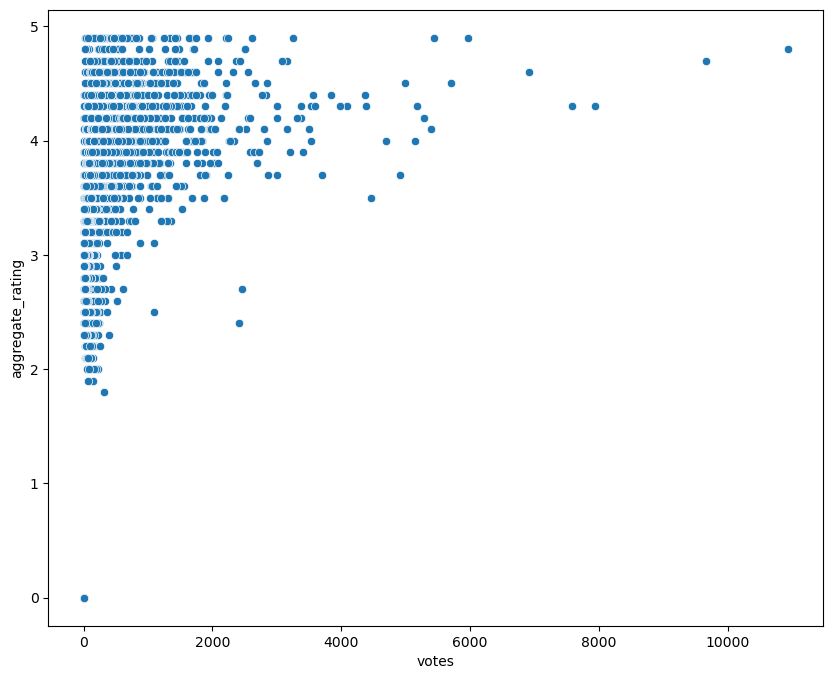

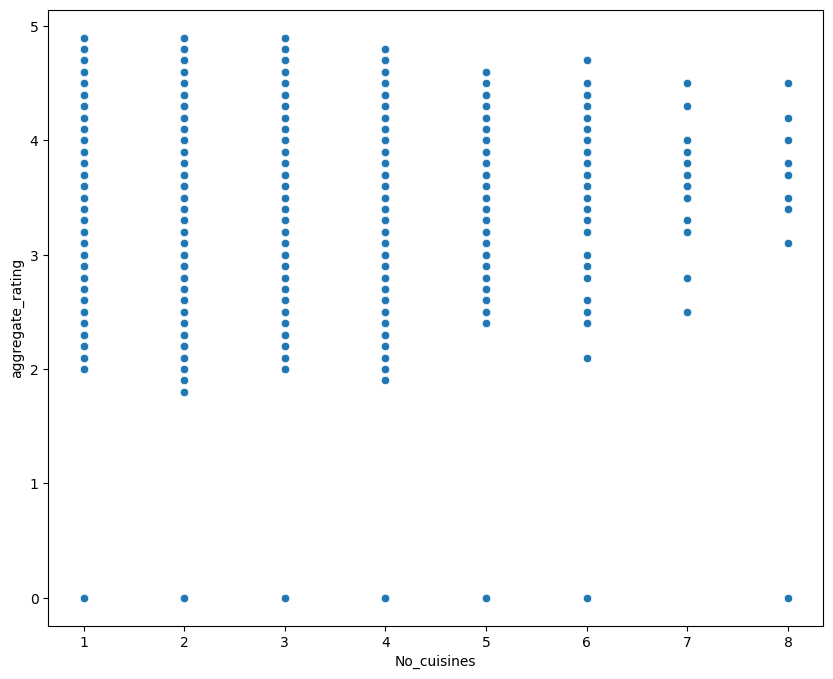

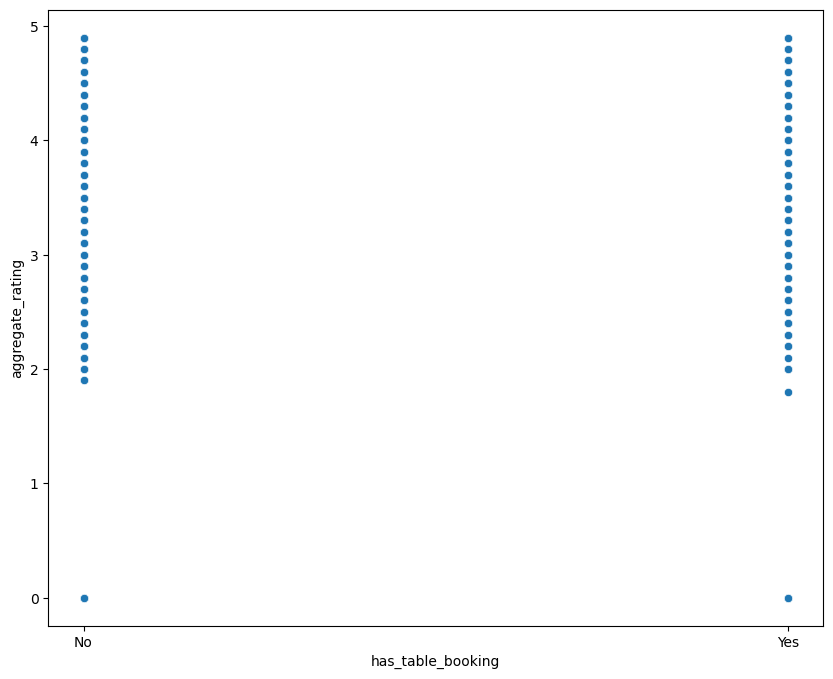

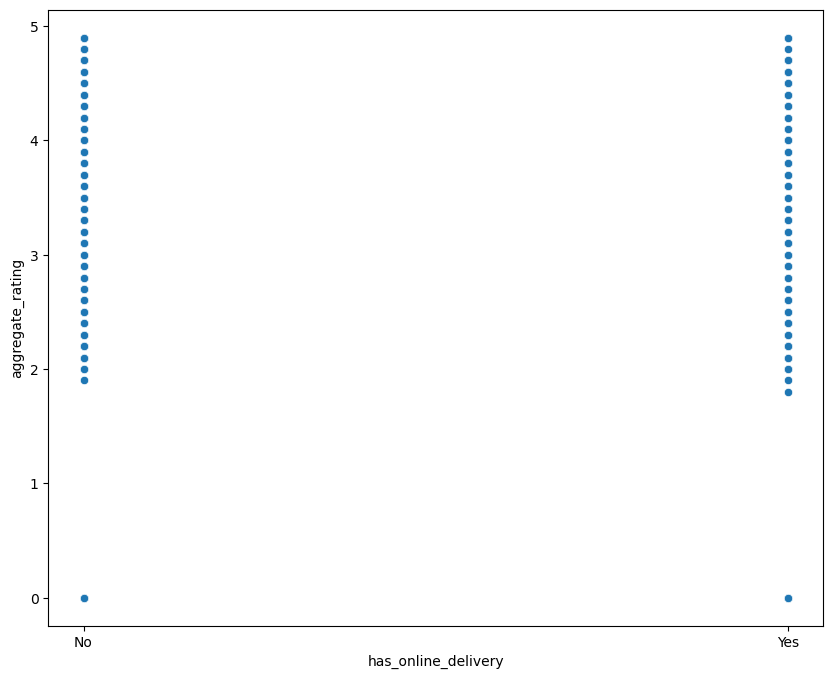

In [61]:
plt.figure(figsize=(10,8))
for i in factors :
    plt.figure(figsize=(10,8))
    sns.scatterplot( x = i , y = 'aggregate_rating' , data = df_cleaned )
    plt.show()

# 5. Explain the factors in the data that may have an effect on ratings. For example, number of cuisines, cost, delivery option, etc

In [63]:
df_cleaned.info()

<class 'pandas.core.frame.DataFrame'>
Index: 9550 entries, 0 to 9550
Data columns (total 20 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   restaurant_id         9550 non-null   int64  
 1   restaurant_name       9550 non-null   object 
 2   country_code          9550 non-null   int64  
 3   city                  9550 non-null   object 
 4   address               9550 non-null   object 
 5   locality              9550 non-null   object 
 6   locality_verbose      9550 non-null   object 
 7   longitude             9550 non-null   float64
 8   latitude              9550 non-null   float64
 9   cuisines              9541 non-null   object 
 10  average_cost_for_two  9550 non-null   int64  
 11  currency              9550 non-null   object 
 12  has_table_booking     9550 non-null   object 
 13  has_online_delivery   9550 non-null   object 
 14  price_range           9550 non-null   int64  
 15  aggregate_rating      9550

In [64]:
 df_copy = df_cleaned.copy()

In [65]:
df_copy.head()

,restaurant_id,restaurant_name,country_code,city,address,locality,locality_verbose,longitude,latitude,cuisines,average_cost_for_two,currency,has_table_booking,has_online_delivery,price_range,aggregate_rating,rating_color,rating_text,votes,No_cuisines
0,7402935,Skye,94,Jakarta,"Menara BCA, Lantai 56, Jl. MH. Thamrin, Thamri...","Grand Indonesia Mall, Thamrin","Grand Indonesia Mall, Thamrin, Jakarta",106.821999,-6.196778,"Italian, Continental",800000,Indonesian Rupiah(IDR),No,No,3,4.1,Green,Very Good,1498,2
1,7410290,Satoo - Hotel Shangri-La,94,Jakarta,"Hotel Shangri-La, Jl. Jend. Sudirman","Hotel Shangri-La, Sudirman","Hotel Shangri-La, Sudirman, Jakarta",106.818961,-6.203292,"Asian, Indonesian, Western",800000,Indonesian Rupiah(IDR),No,No,3,4.6,Dark Green,Excellent,873,3
2,7420899,Sushi Masa,94,Jakarta,"Jl. Tuna Raya No. 5, Penjaringan",Penjaringan,"Penjaringan, Jakarta",106.800144,-6.101298,"Sushi, Japanese",500000,Indonesian Rupiah(IDR),No,No,3,4.9,Dark Green,Excellent,605,2
3,7421967,3 Wise Monkeys,94,Jakarta,"Jl. Suryo No. 26, Senopati, Jakarta",Senopati,"Senopati, Jakarta",106.813400,-6.235241,Japanese,450000,Indonesian Rupiah(IDR),No,No,3,4.2,Green,Very Good,395,1
4,7422489,Avec Moi Restaurant and Bar,94,Jakarta,"Gedung PIC, Jl. Teluk Betung 43, Thamrin, Jakarta",Thamrin,"Thamrin, Jakarta",106.821023,-6.196270,"French, Western",350000,Indonesian Rupiah(IDR),No,No,3,4.3,Green,Very Good,243,2


In [66]:
dummy_booking = pd.get_dummies(df_copy.has_table_booking).astype('int64')

In [67]:
dummy_delivery = pd.get_dummies(df_copy.has_online_delivery).astype('int64')

In [68]:
df_copy_latest = pd.concat([df_copy , dummy_booking , dummy_delivery ] , axis = 'columns')

In [69]:
df_copy_latest.head()

,restaurant_id,restaurant_name,country_code,city,address,locality,locality_verbose,longitude,latitude,cuisines,...,price_range,aggregate_rating,rating_color,rating_text,votes,No_cuisines,No,Yes,No,Yes
0,7402935,Skye,94,Jakarta,"Menara BCA, Lantai 56, Jl. MH. Thamrin, Thamri...","Grand Indonesia Mall, Thamrin","Grand Indonesia Mall, Thamrin, Jakarta",106.821999,-6.196778,"Italian, Continental",...,3,4.1,Green,Very Good,1498,2,1,0,1,0
1,7410290,Satoo - Hotel Shangri-La,94,Jakarta,"Hotel Shangri-La, Jl. Jend. Sudirman","Hotel Shangri-La, Sudirman","Hotel Shangri-La, Sudirman, Jakarta",106.818961,-6.203292,"Asian, Indonesian, Western",...,3,4.6,Dark Green,Excellent,873,3,1,0,1,0
2,7420899,Sushi Masa,94,Jakarta,"Jl. Tuna Raya No. 5, Penjaringan",Penjaringan,"Penjaringan, Jakarta",106.800144,-6.101298,"Sushi, Japanese",...,3,4.9,Dark Green,Excellent,605,2,1,0,1,0
3,7421967,3 Wise Monkeys,94,Jakarta,"Jl. Suryo No. 26, Senopati, Jakarta",Senopati,"Senopati, Jakarta",106.813400,-6.235241,Japanese,...,3,4.2,Green,Very Good,395,1,1,0,1,0
4,7422489,Avec Moi Restaurant and Bar,94,Jakarta,"Gedung PIC, Jl. Teluk Betung 43, Thamrin, Jakarta",Thamrin,"Thamrin, Jakarta",106.821023,-6.196270,"French, Western",...,3,4.3,Green,Very Good,243,2,1,0,1,0


In [70]:
df_copy_latest.info()

<class 'pandas.core.frame.DataFrame'>
Index: 9550 entries, 0 to 9550
Data columns (total 24 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   restaurant_id         9550 non-null   int64  
 1   restaurant_name       9550 non-null   object 
 2   country_code          9550 non-null   int64  
 3   city                  9550 non-null   object 
 4   address               9550 non-null   object 
 5   locality              9550 non-null   object 
 6   locality_verbose      9550 non-null   object 
 7   longitude             9550 non-null   float64
 8   latitude              9550 non-null   float64
 9   cuisines              9541 non-null   object 
 10  average_cost_for_two  9550 non-null   int64  
 11  currency              9550 non-null   object 
 12  has_table_booking     9550 non-null   object 
 13  has_online_delivery   9550 non-null   object 
 14  price_range           9550 non-null   int64  
 15  aggregate_rating      9550

In [71]:
df_copy_latest = df_copy_latest.rename(columns  = {'No' : 'has_table_booking(No)' , 'Yes' : 'has_table_booking(Yes)' , 'No' : 'has_online_delivery(No)' , 'Yes' : 'has_online_delivery(Yes)'})

In [72]:
df_copy_latest.columns

Index(['restaurant_id', 'restaurant_name', 'country_code', 'city', 'address',
       'locality', 'locality_verbose', 'longitude', 'latitude', 'cuisines',
       'average_cost_for_two', 'currency', 'has_table_booking',
       'has_online_delivery', 'price_range', 'aggregate_rating',
       'rating_color', 'rating_text', 'votes', 'No_cuisines',
       'has_online_delivery(No)', 'has_online_delivery(Yes)',
       'has_online_delivery(No)', 'has_online_delivery(Yes)'],
      dtype='object')

In [73]:
df_copy_latest.columns.values[20] = 'has_table_booking(No)'
df_copy_latest.columns.values[21] = 'has_table_booking(Yes)'

In [74]:
df_copy_latest.corr(numeric_only=True)

,restaurant_id,country_code,longitude,latitude,average_cost_for_two,price_range,aggregate_rating,votes,No_cuisines,has_table_booking(No),has_table_booking(Yes),has_online_delivery(No),has_online_delivery(Yes)
restaurant_id,1.000000,0.148447,-0.226073,-0.052111,-0.001696,-0.134419,-0.326144,-0.146895,-0.074624,0.110118,-0.110118,0.085157,-0.085157
country_code,0.148447,1.000000,-0.698298,0.019784,0.043224,0.243393,0.282234,0.154593,0.009035,0.061695,-0.061695,0.154627,-0.154627
longitude,-0.226073,-0.698298,1.000000,0.043213,0.045892,-0.078974,-0.116843,-0.085141,0.014792,-0.100497,0.100497,-0.178773,0.178773
latitude,-0.052111,0.019784,0.043213,1.000000,-0.111089,-0.166668,0.000541,-0.022927,-0.028972,-0.054648,0.054648,-0.118709,0.118709
average_cost_for_two,-0.001696,0.043224,0.045892,-0.111089,1.000000,0.075093,0.051797,0.067794,0.013348,-0.007757,0.007757,0.018976,-0.018976
price_range,-0.134419,0.243393,-0.078974,-0.166668,0.075093,1.000000,0.437874,0.309308,0.312773,-0.502025,0.502025,-0.078007,0.078007
aggregate_rating,-0.326144,0.282234,-0.116843,0.000541,0.051797,0.437874,1.000000,0.313598,0.249271,-0.190045,0.190045,-0.225772,0.225772
votes,-0.146895,0.154593,-0.085141,-0.022927,0.067794,0.309308,0.313598,1.000000,0.183217,-0.169497,0.169497,-0.074399,0.074399
No_cuisines,-0.074624,0.009035,0.014792,-0.028972,0.013348,0.312773,0.249271,0.183217,1.000000,-0.222977,0.222977,-0.162631,0.162631
has_table_booking(No),0.110118,0.061695,-0.100497,-0.054648,-0.007757,-0.502025,-0.190045,-0.169497,-0.222977,1.000000,-1.000000,0.101204,-0.101204


In [75]:
# From the above correlation matrix , aggregate rating has some correlation with restaurant_id (-0.326144), price_range (0.437874), votes (0.313598). 

In [76]:
factors = ['restaurant_id' , 'price_range' , 'votes' , 'has_table_booking(No)' ,'has_table_booking(Yes)' , 'has_online_delivery(No)' , 'has_online_delivery(Yes)']


<Figure size 1000x1200 with 0 Axes>

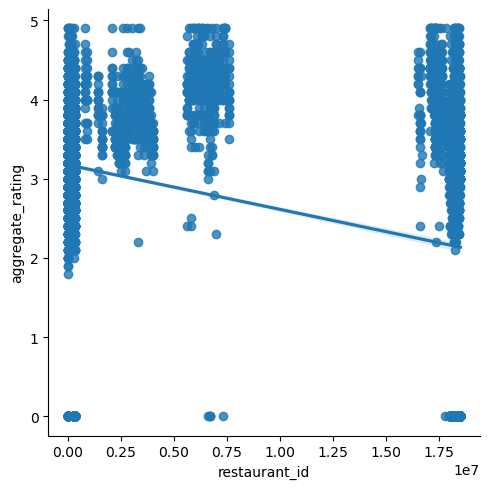

<Figure size 1000x1200 with 0 Axes>

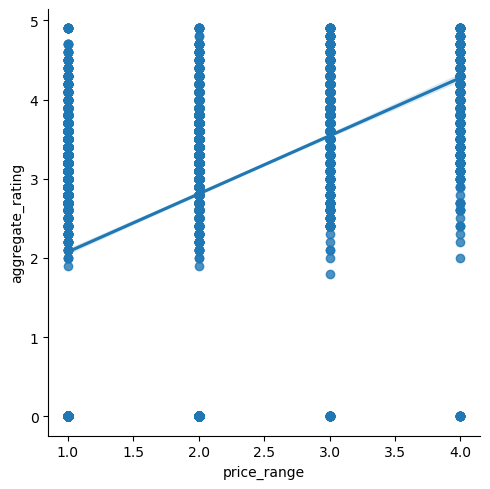

<Figure size 1000x1200 with 0 Axes>

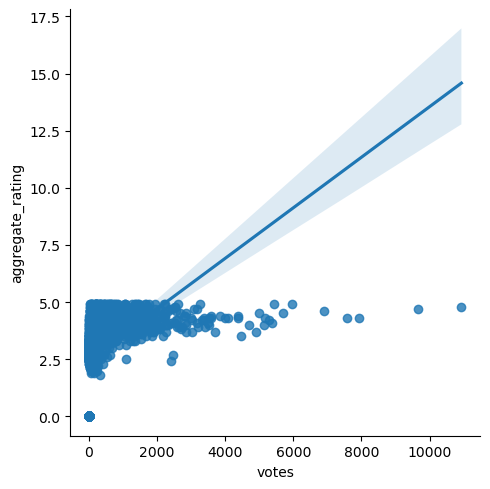

<Figure size 1000x1200 with 0 Axes>

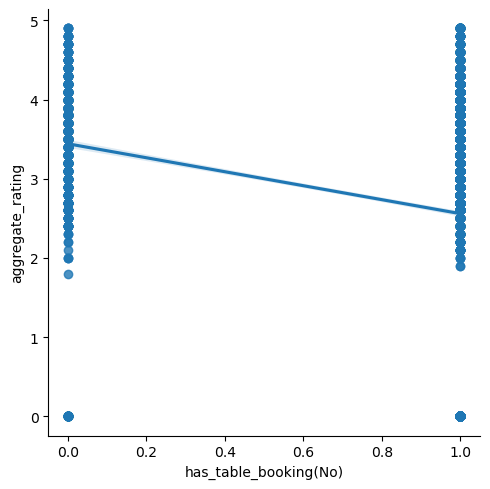

<Figure size 1000x1200 with 0 Axes>

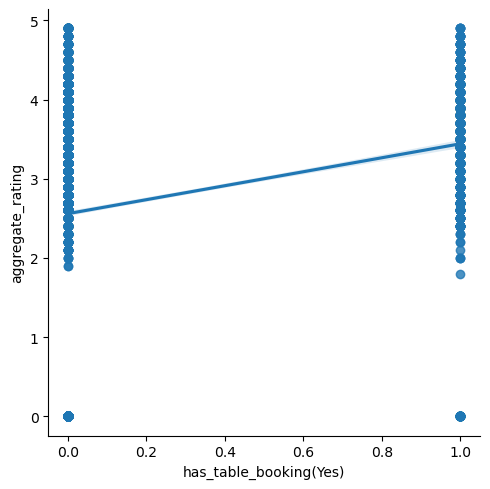

<Figure size 1000x1200 with 0 Axes>

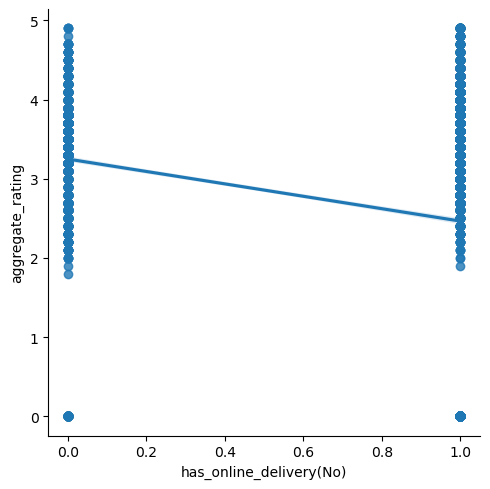

<Figure size 1000x1200 with 0 Axes>

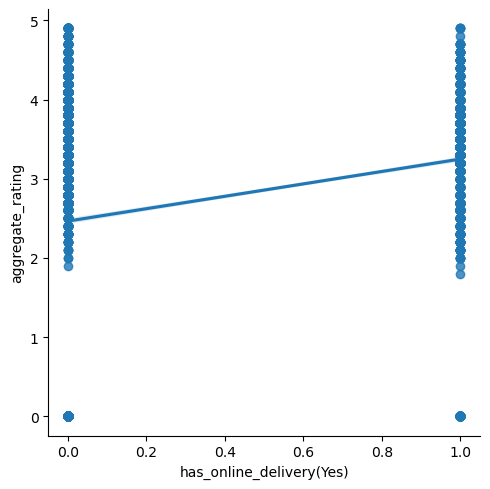

In [77]:
for i in factors :
    plt.figure(figsize=(10,12))
    sns.lmplot(x = i , y = 'aggregate_rating' ,  data = df_copy_latest)
    plt.show()

# Observations

1. Restaurants with smaller restaurant id's are given more ratings than the higher restaurant id's
2. Ratings for the restaurants increases with the increase in price range
3. Most of the ratings are given to the restaurants whose votes are from 0 to 4000
4. Restaurants offering online table booking option are given more ratings than the one's not offering online table booking option
5. Restaurants offering online delivery option are given more ratings than the one's not offering online delivery options

# 6. Visualize the variables using Tableau to help user explore the data and create a better understanding of the restaurants to identify the ‘’star’’ restaurant

In [81]:
df_cleaned.info()

<class 'pandas.core.frame.DataFrame'>
Index: 9550 entries, 0 to 9550
Data columns (total 20 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   restaurant_id         9550 non-null   int64  
 1   restaurant_name       9550 non-null   object 
 2   country_code          9550 non-null   int64  
 3   city                  9550 non-null   object 
 4   address               9550 non-null   object 
 5   locality              9550 non-null   object 
 6   locality_verbose      9550 non-null   object 
 7   longitude             9550 non-null   float64
 8   latitude              9550 non-null   float64
 9   cuisines              9541 non-null   object 
 10  average_cost_for_two  9550 non-null   int64  
 11  currency              9550 non-null   object 
 12  has_table_booking     9550 non-null   object 
 13  has_online_delivery   9550 non-null   object 
 14  price_range           9550 non-null   int64  
 15  aggregate_rating      9550

In [82]:
# Saving the updated and cleaned data in an excel file name as data_cleaned
df_cleaned.to_excel('data_cleaned.xlsx', index = False)

<Figure size 1000x1200 with 0 Axes>

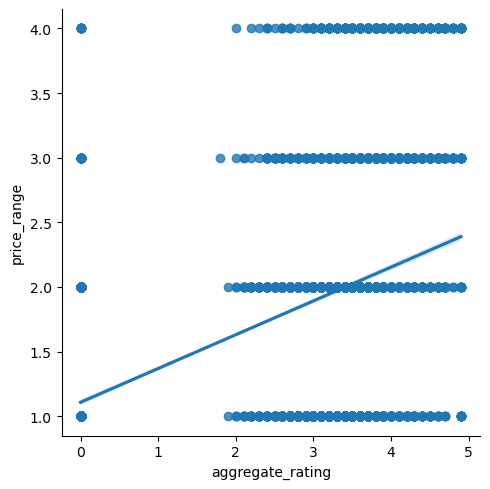

In [83]:
plt.figure(figsize=(10,12))
sns.lmplot(y = 'price_range' , x = 'aggregate_rating' ,  data = df_copy_latest)
plt.show()